# Cognifyz Data Science Internship
# Name: RAGHUL K
## Email ID: raghul1826@gmail.com
## Level 1 — Tasks 1, 2 & 3
**Dataset:** Zomato Restaurant Dataset  
**Level 1 covers:** Data Exploration & Preprocessing | Descriptive Analysis | Geospatial Analysis

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("C:/Users/RAGHUL K/OneDrive/Documents/Jupyter/Dataset.csv")
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 9551 rows × 21 columns


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


---
## Task 1 — Data Exploration & Preprocessing

### 1.1 — Dataset Shape & Column Overview

In [3]:
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print('\nColumn names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

Rows    : 9551
Columns : 21

Column names:
   1. Restaurant ID
   2. Restaurant Name
   3. Country Code
   4. City
   5. Address
   6. Locality
   7. Locality Verbose
   8. Longitude
   9. Latitude
  10. Cuisines
  11. Average Cost for two
  12. Currency
  13. Has Table booking
  14. Has Online delivery
  15. Is delivering now
  16. Switch to order menu
  17. Price range
  18. Aggregate rating
  19. Rating color
  20. Rating text
  21. Votes


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

### 1.2 — Missing Value Analysis

          Missing Count  Missing %
Cuisines              9       0.09


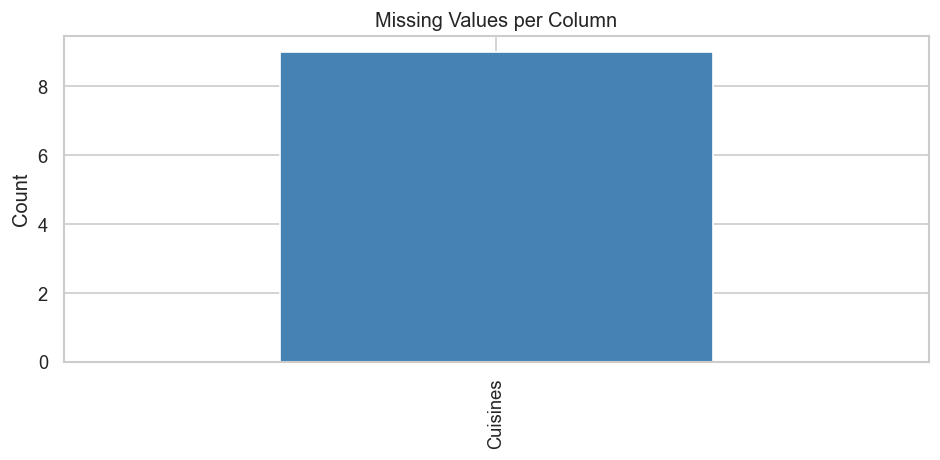

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('No missing values found — except:')

print(missing_df)

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
cols_with_missing = df.isnull().sum()
cols_with_missing = cols_with_missing[cols_with_missing > 0]
if not cols_with_missing.empty:
    cols_with_missing.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Missing Values per Column')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('Only "Cuisines" has 9 missing values (<0.1%).')

### 1.3 — Handling Missing Values

In [6]:
# Fill the 9 missing Cuisines entries with 'Unknown'
df['Cuisines'].fillna('Unknown', inplace=True)

print('Missing values after treatment:')
print(df.isnull().sum().sum(), '← total nulls remaining')

Missing values after treatment:
9 ← total nulls remaining


### 1.4 — Data Type Conversion

In [7]:
# Binary Yes/No columns → integer (1/0)
binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print('Data types after conversion:')
print(df[binary_cols].dtypes)

Data types after conversion:
Has Table booking       int64
Has Online delivery     int64
Is delivering now       int64
Switch to order menu    int64
dtype: object


### 1.5 — Target Variable: Aggregate Rating Distribution

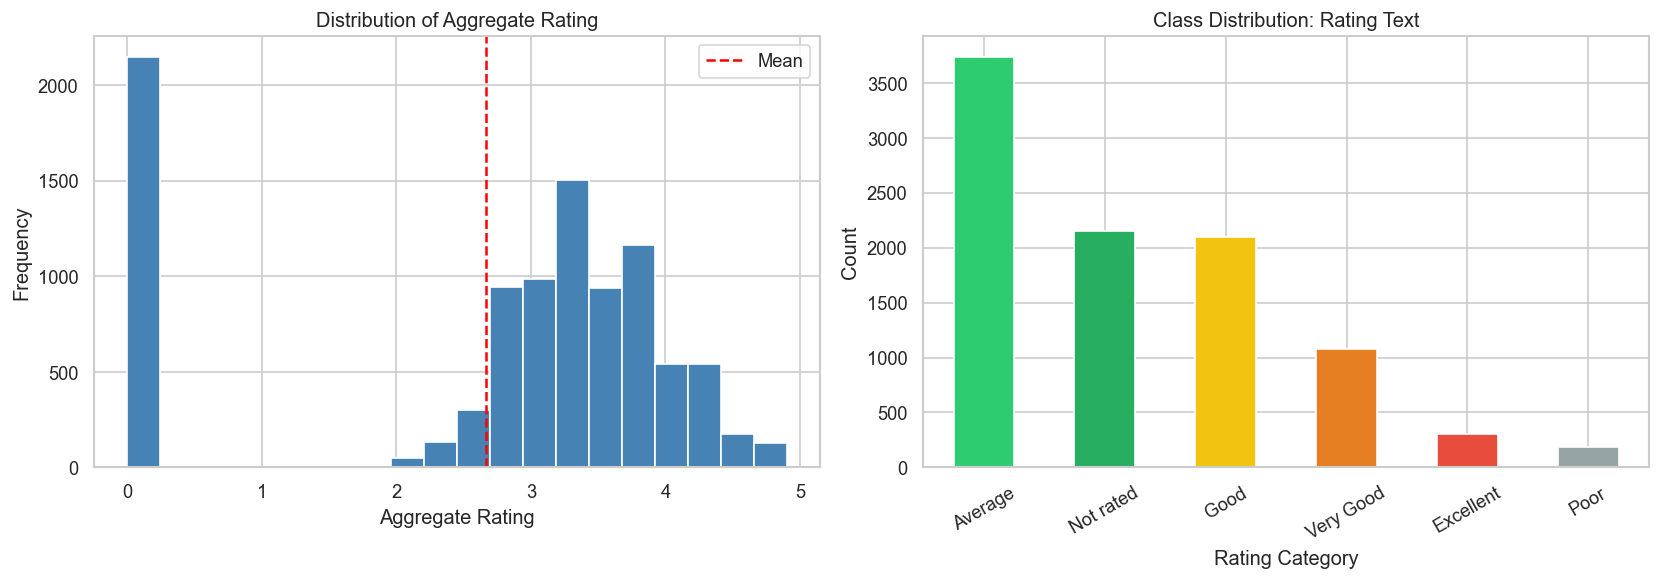


Class Imbalance Summary:
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

⚠ "Not rated" accounts for 2148 entries (22.5%) — major class imbalance.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Aggregate rating'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Aggregate Rating')
axes[0].set_xlabel('Aggregate Rating')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Aggregate rating'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

# Rating text class distribution (class imbalance check)
rating_counts = df['Rating text'].value_counts()
colors = ['#2ecc71','#27ae60','#f1c40f','#e67e22','#e74c3c','#95a5a6','#bdc3c7']
rating_counts.plot(kind='bar', ax=axes[1], color=colors[:len(rating_counts)], edgecolor='white')
axes[1].set_title('Class Distribution: Rating Text')
axes[1].set_xlabel('Rating Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('\nClass Imbalance Summary:')
print(df['Rating text'].value_counts())
print(f'\n⚠ "Not rated" accounts for {(df["Aggregate rating"]==0).sum()} entries ({(df["Aggregate rating"]==0).mean()*100:.1f}%) — major class imbalance.')

**Key Finding:** The dataset has a significant class imbalance — ~22.5% of restaurants have a rating of 0.0 ("Not rated"). This should be addressed before any predictive modeling.

---
## Task 2 — Descriptive Analysis

### 2.1 — Basic Statistical Measures (Numerical Columns)

In [9]:
num_cols = ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']
stats = df[num_cols].agg(['mean', 'median', 'std', 'min', 'max', 'skew'])
stats.loc['mean'] = stats.loc['mean'].round(2)
stats.loc['std']  = stats.loc['std'].round(2)
stats.loc['skew'] = stats.loc['skew'].round(2)
print('Statistical Summary:')
stats

Statistical Summary:


,Average Cost for two,Price range,Aggregate rating,Votes
mean,1199.21,1.80,2.67,156.91
median,400.00,2.00,3.20,31.00
std,16121.18,0.91,1.52,430.17
min,0.00,1.00,0.00,0.00
max,800000.00,4.00,4.90,10934.00
skew,35.48,0.89,-0.95,8.81


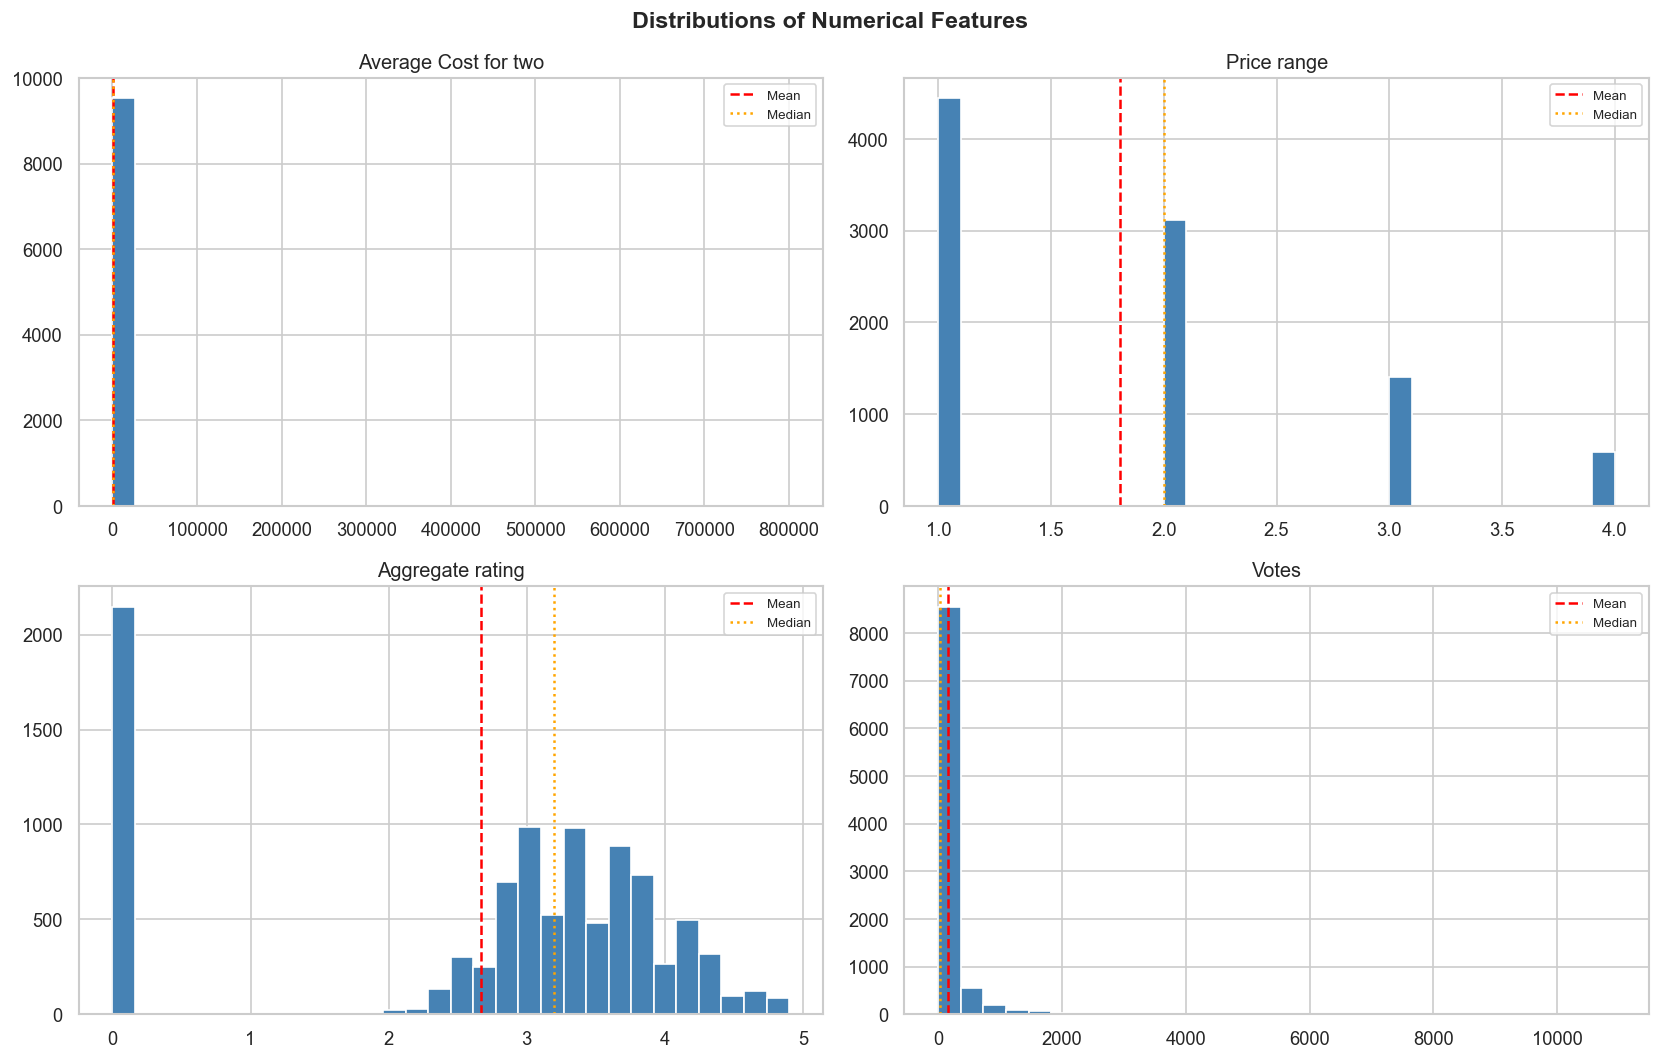

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle=':',  linewidth=1.5, label='Median')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Distributions of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 — Categorical Variable: Country Code

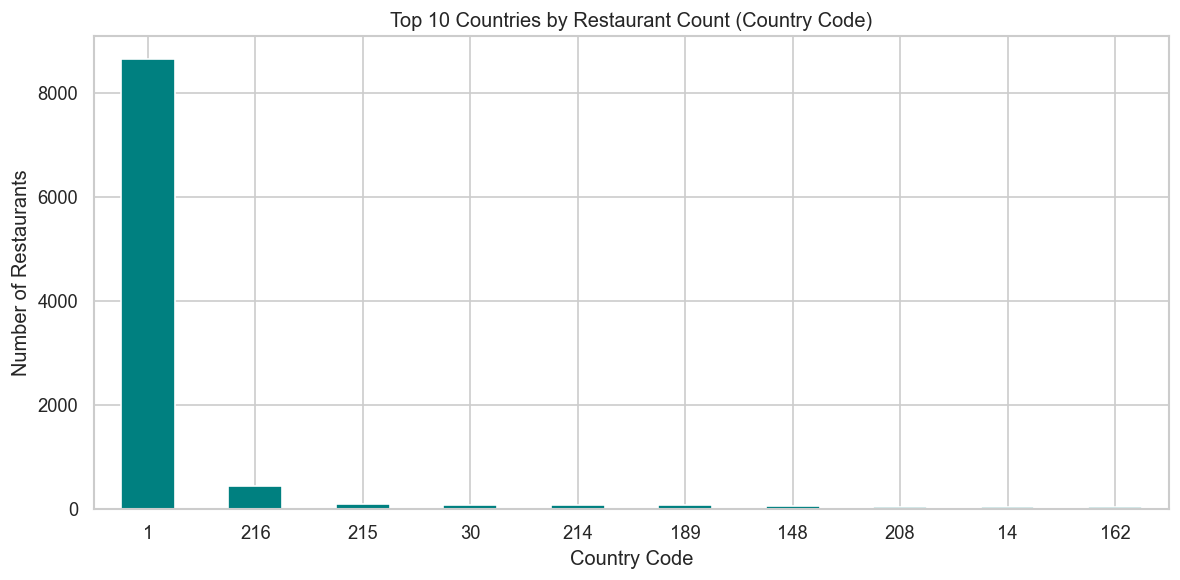

Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
Name: count, dtype: int64


In [11]:
country_counts = df['Country Code'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
country_counts.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Top 10 Countries by Restaurant Count (Country Code)')
ax.set_xlabel('Country Code')
ax.set_ylabel('Number of Restaurants')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(country_counts)

### 2.3 — Top Cities by Restaurant Count

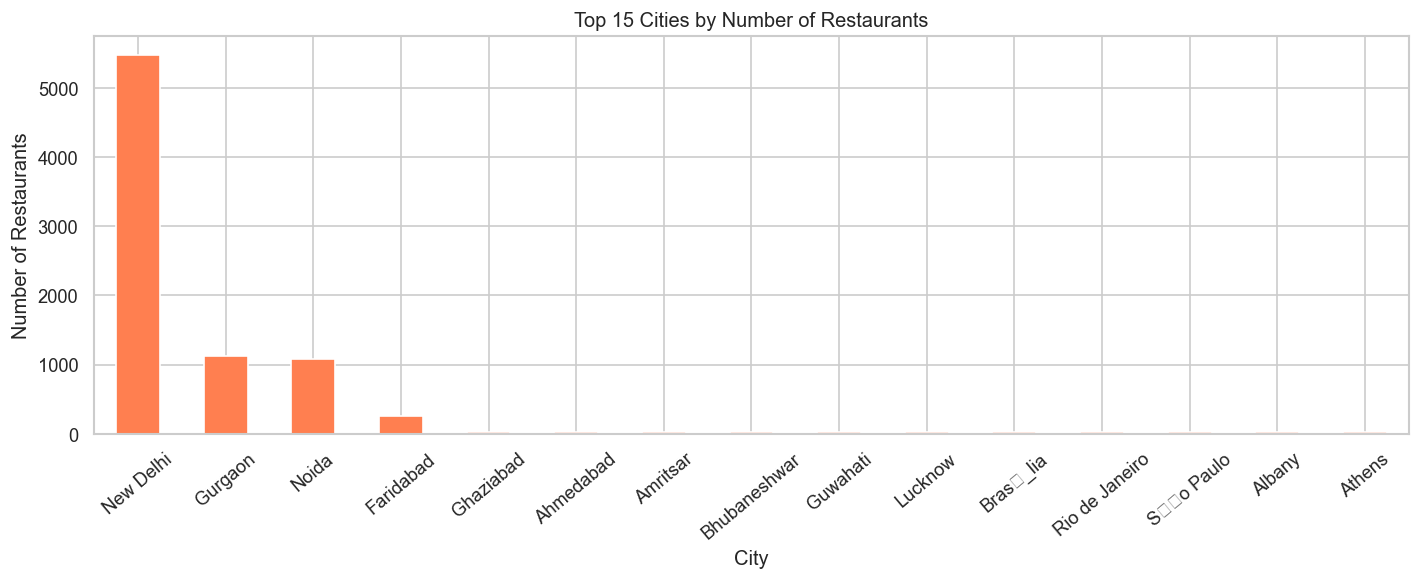

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
Ahmedabad           21
Amritsar            21
Bhubaneshwar        21
Guwahati            21
Lucknow             21
Bras�_lia           20
Rio de Janeiro      20
S��o Paulo          20
Albany              20
Athens              20
Name: count, dtype: int64


In [12]:
top_cities = df['City'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
top_cities.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Top 15 Cities by Number of Restaurants')
ax.set_xlabel('City')
ax.set_ylabel('Number of Restaurants')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

print(top_cities)

### 2.4 — Top Individual Cuisines

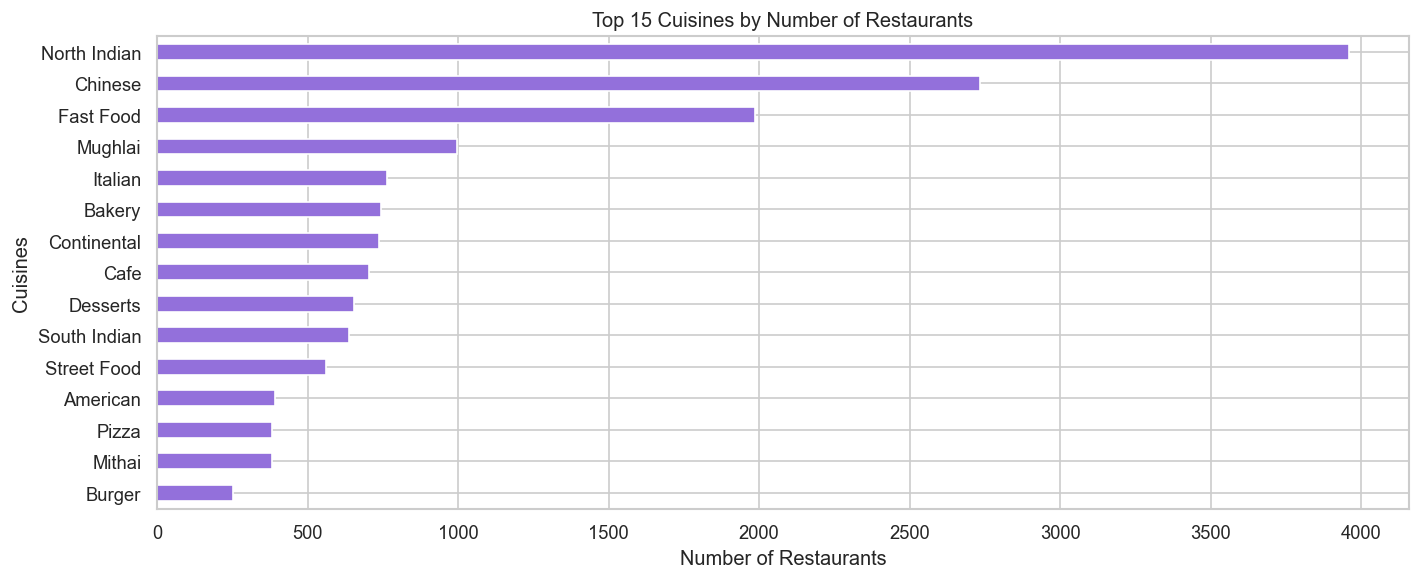

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Street Food      562
American         390
Pizza            381
Mithai           380
Burger           251
Name: count, dtype: int64


In [13]:
# Each restaurant may list multiple cuisines — explode to count individually
cuisine_series = df['Cuisines'].str.split(', ').explode()
top_cuisines = cuisine_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
top_cuisines.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Cuisines by Number of Restaurants')
ax.set_xlabel('Number of Restaurants')
plt.tight_layout()
plt.show()

print(top_cuisines)

---
## Task 3 — Geospatial Analysis

### 3.1 — Restaurant Locations on World Map

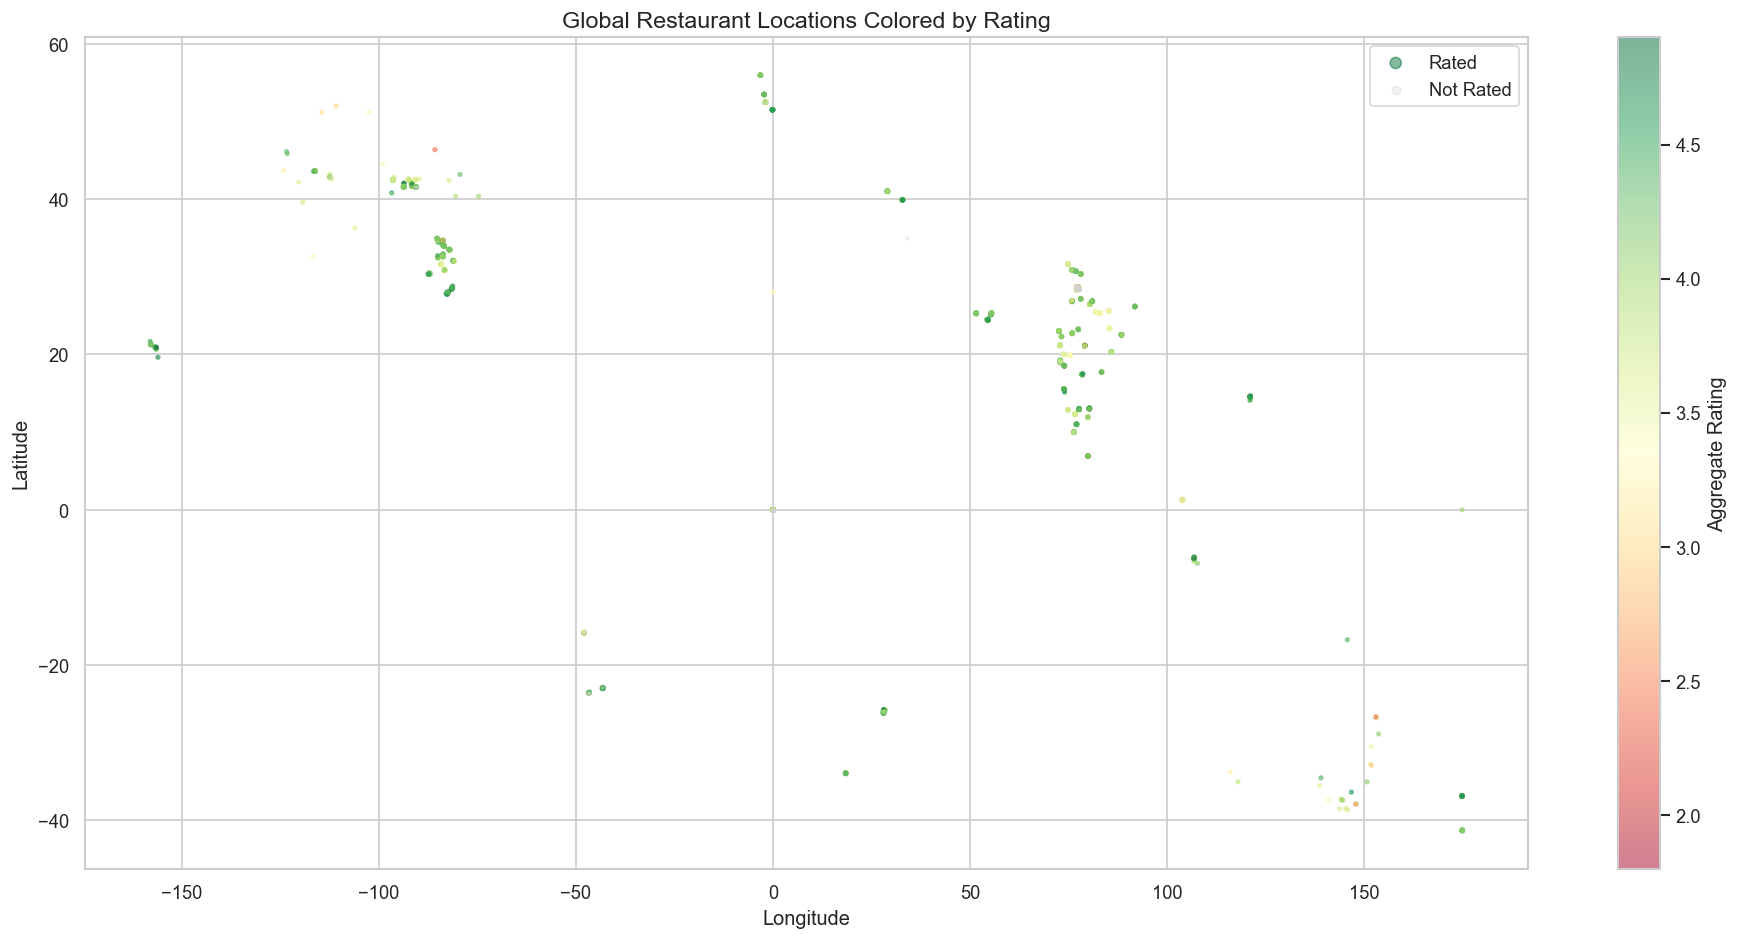

In [14]:
fig, ax = plt.subplots(figsize=(16, 8))

# Color by rating
rated = df[df['Aggregate rating'] > 0]
not_rated = df[df['Aggregate rating'] == 0]

sc = ax.scatter(
    rated['Longitude'], rated['Latitude'],
    c=rated['Aggregate rating'], cmap='RdYlGn',
    s=5, alpha=0.5, label='Rated'
)
ax.scatter(
    not_rated['Longitude'], not_rated['Latitude'],
    color='lightgray', s=3, alpha=0.3, label='Not Rated'
)

plt.colorbar(sc, ax=ax, label='Aggregate Rating')
ax.set_title('Global Restaurant Locations Colored by Rating', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

### 3.2 — Restaurant Distribution Across Cities

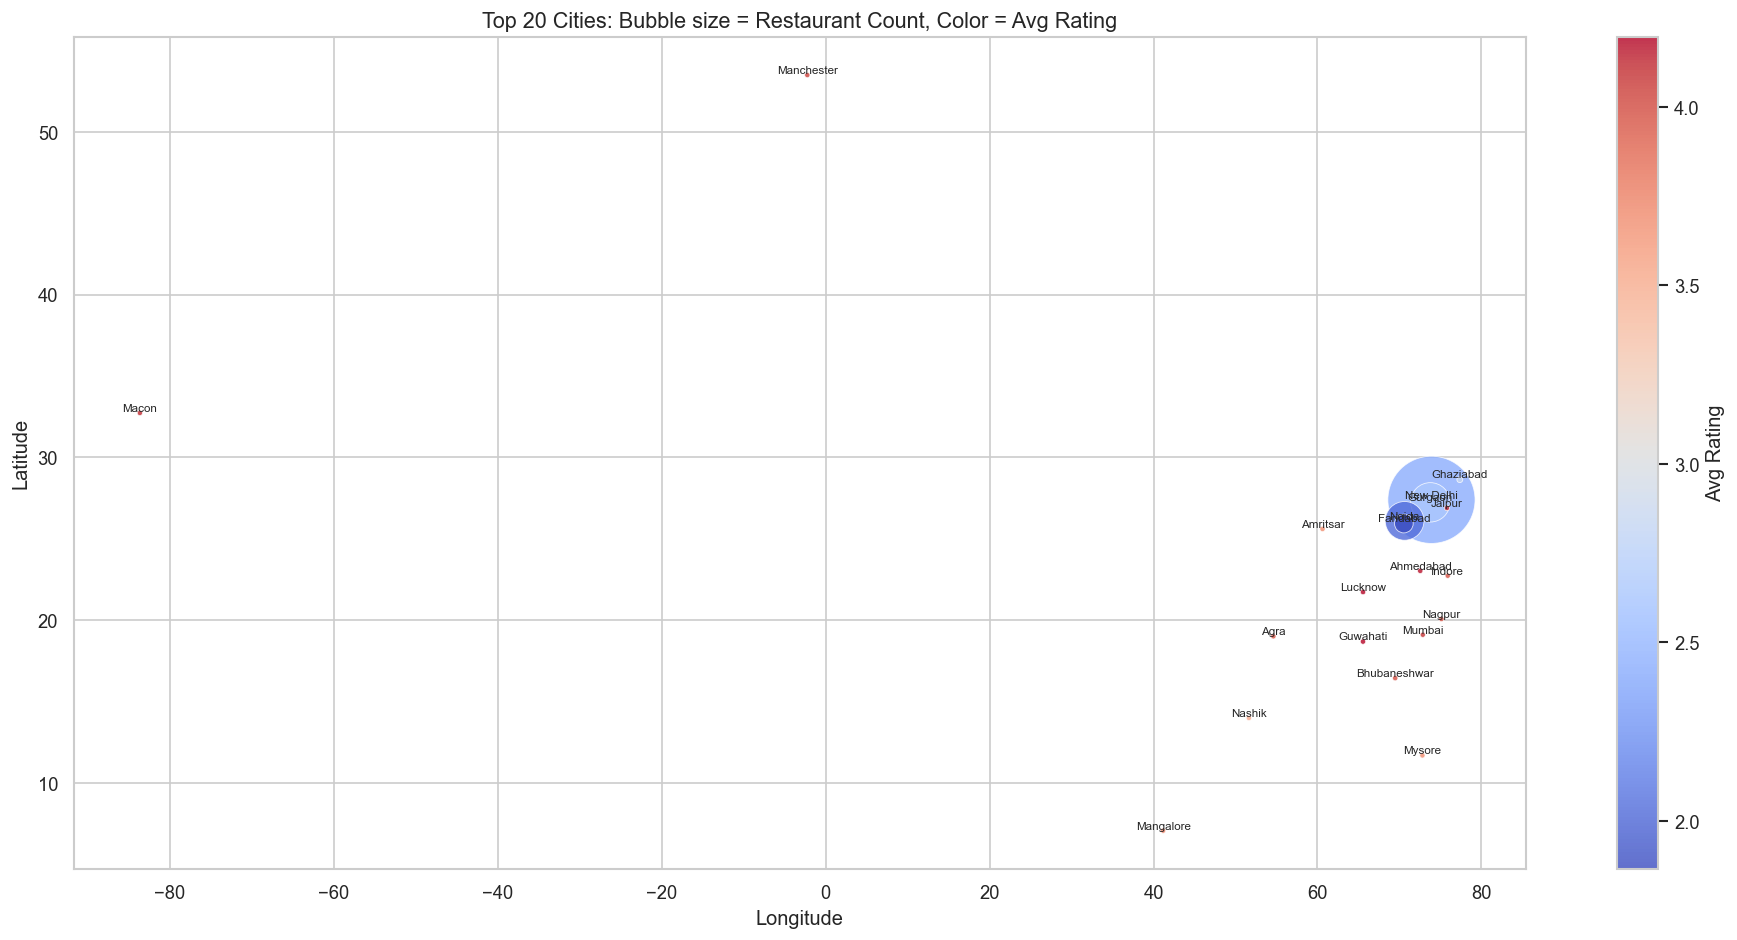

In [15]:
# Top 10 cities — average lat/lon + count
city_stats = df.groupby('City').agg(
    count=('Restaurant ID', 'count'),
    avg_lat=('Latitude', 'mean'),
    avg_lon=('Longitude', 'mean'),
    avg_rating=('Aggregate rating', 'mean')
).reset_index().sort_values('count', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(16, 8))
sc = ax.scatter(
    city_stats['avg_lon'], city_stats['avg_lat'],
    s=city_stats['count'] * 0.5,
    c=city_stats['avg_rating'], cmap='coolwarm',
    alpha=0.8, edgecolors='white', linewidth=0.5
)
for _, row in city_stats.iterrows():
    ax.annotate(row['City'], (row['avg_lon'], row['avg_lat']),
                fontsize=7, ha='center', va='bottom')

plt.colorbar(sc, ax=ax, label='Avg Rating')
ax.set_title('Top 20 Cities: Bubble size = Restaurant Count, Color = Avg Rating', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

### 3.3 — Correlation Between Location and Rating

Correlation — Latitude  vs Rating: -0.1799
Correlation — Longitude vs Rating: -0.2915


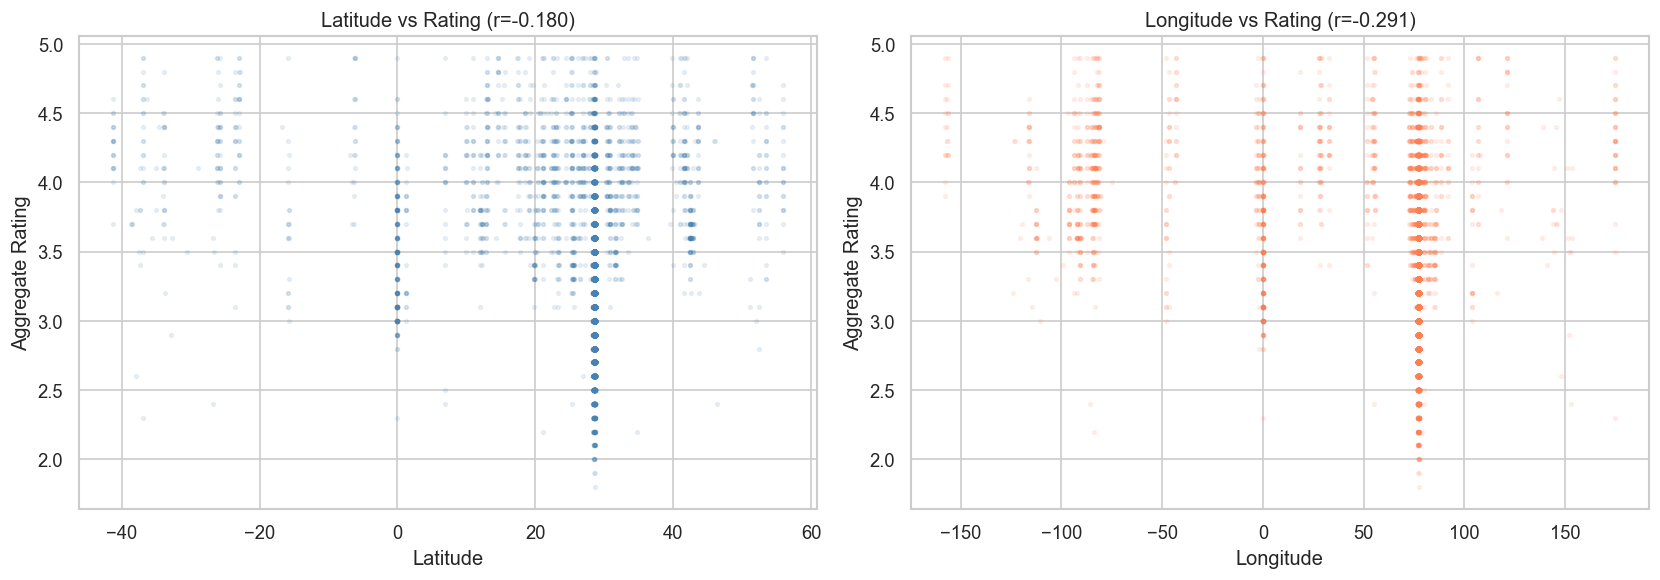

In [16]:
# Exclude unrated restaurants from correlation analysis
rated_df = df[df['Aggregate rating'] > 0].copy()

corr_lat  = rated_df['Latitude'].corr(rated_df['Aggregate rating'])
corr_lon  = rated_df['Longitude'].corr(rated_df['Aggregate rating'])
print(f'Correlation — Latitude  vs Rating: {corr_lat:.4f}')
print(f'Correlation — Longitude vs Rating: {corr_lon:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rated_df['Latitude'], rated_df['Aggregate rating'],
                alpha=0.1, s=5, color='steelblue')
axes[0].set_title(f'Latitude vs Rating (r={corr_lat:.3f})')
axes[0].set_xlabel('Latitude')
axes[0].set_ylabel('Aggregate Rating')

axes[1].scatter(rated_df['Longitude'], rated_df['Aggregate rating'],
                alpha=0.1, s=5, color='coral')
axes[1].set_title(f'Longitude vs Rating (r={corr_lon:.3f})')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Aggregate Rating')

plt.tight_layout()
plt.show()

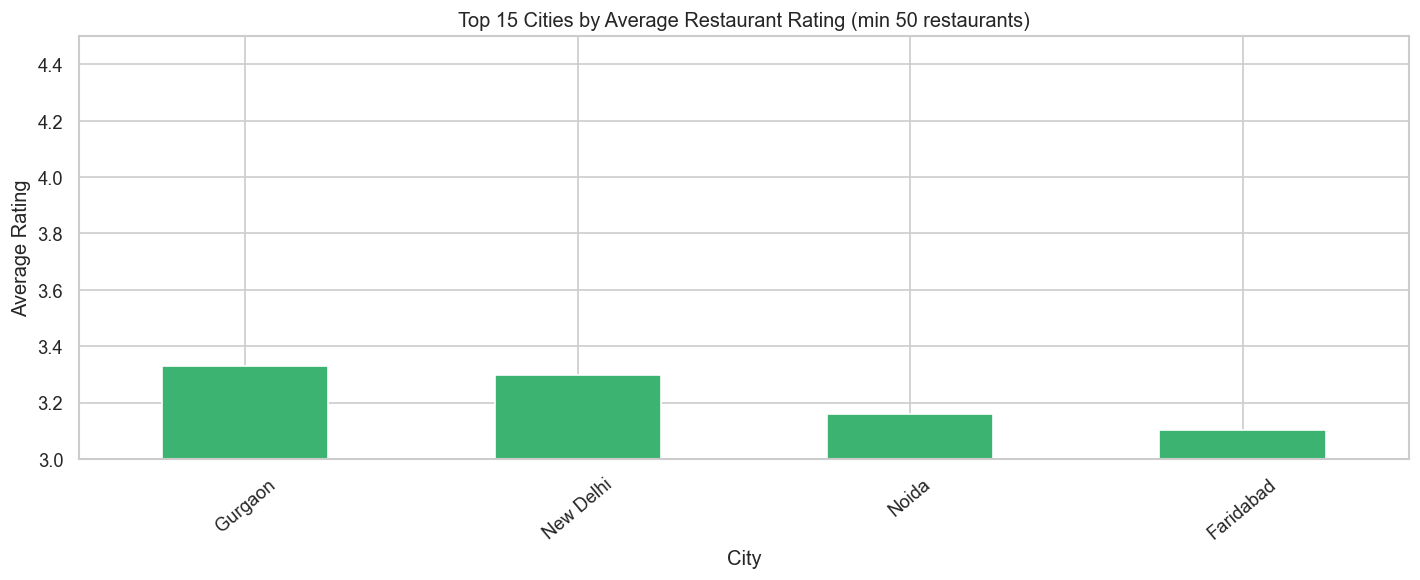

            mean  count
City                   
Gurgaon    3.331    890
New Delhi  3.297   4048
Noida      3.160    696
Faridabad  3.103    151


In [17]:
# Average rating by city (Top 15 cities)
city_avg_rating = (
    rated_df.groupby('City')['Aggregate rating']
    .agg(['mean', 'count'])
    .query('count >= 50')       # only cities with meaningful sample
    .sort_values('mean', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 5))
city_avg_rating['mean'].plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Top 15 Cities by Average Restaurant Rating (min 50 restaurants)')
ax.set_ylabel('Average Rating')
ax.set_ylim(3.0, 4.5)
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

print(city_avg_rating.round(3))

**Key Geospatial Finding:** Latitude and Longitude individually show very weak correlation with rating. However, grouping by city reveals that specific cities (like Inner City) consistently maintain higher average ratings, suggesting that geographic clustering — rather than raw coordinates — is a better predictor.

In [18]:
print('='*50)
print('Level 1 Complete ✓')
print('='*50)
print(f'Final dataset shape  : {df.shape}')
print(f'Missing values left  : {df.isnull().sum().sum()}')
print(f'Binary cols encoded  : {binary_cols}')

Level 1 Complete ✓
Final dataset shape  : (9551, 21)
Missing values left  : 9
Binary cols encoded  : ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
